# 04: Results Summary

## 1. Introduction

This notebook combines the scored grids from both study areas (produced by
Notebook 03), produces the ranked underserved-settlement list referenced
throughout the project's narrative materials, and exports the summary
tables used in the written report and ArcGIS StoryMap.

Where Notebooks 01–03 each focused on producing *one* dataset (extracted
layers, completeness flags, access scores), this notebook is the first
point where the two study areas and three transport modes are actually
compared side by side.
### What this notebook covers

1. Imports
2. Configuration
3. Combining both LGAs' scored grids into one dataset
4. Cross-mode comparison (walk vs. okada vs. drive)
5. Cross-LGA comparison (Akure North vs. Akure South)
6. Completeness cross-check
7. Ranked underserved-settlement list
8. Summary charts
9. Exporting report-ready tables

### Expected outputs

Three CSV summary tables and one combined GeoJSON dataset (see Section 7,
Export).

### Prerequisites

- Notebooks 01–03 have been run for both study areas.

## 2. Imports

No new external dependencies here beyond what earlier notebooks already
used: `geopandas`/`pandas` for combining and summarizing the scored grids,
and `matplotlib` (imported later, Section 6) for the summary charts.

### 2.1 Environment setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
DASHBOARD_DRIVE_FOLDER = "Akure Access Dashboard"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DASHBOARD_DIR = f"/content/drive/MyDrive/{DASHBOARD_DRIVE_FOLDER}"
    if not os.path.exists(DASHBOARD_DIR):
        raise FileNotFoundError(f"Expected '{DASHBOARD_DIR}' in your Google Drive.")

    %cd {DASHBOARD_DIR}/notebooks
    !pip install geopandas shapely fiona pandas numpy matplotlib --quiet
    print(f"Running in Colab. Working directory: {os.getcwd()}")
else:
    print("Running locally.")


Mounted at /content/drive
/content/drive/MyDrive/Akure Access Dashboard/notebooks
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 43.5 MB/s eta 0:00:00
Running in Colab. Working directory: /content/drive/MyDrive/Akure Access Dashboard/notebooks


## 3. Configuration

`LGA_DATA_DIRS` and `MODES` are redeclared here (matching Notebook 03)
rather than passed between notebooks, so this notebook can be re-run
independently once Notebook 03's outputs exist on disk.

## 4. Data Loading

### 4.1 Combining both study areas

Loads the scored grid for each LGA (from Notebook 03) and concatenates
them into a single combined dataset, tagged by LGA, for cross-area
analysis. This is the first time in the pipeline both LGAs exist in one
DataFrame, every notebook before this processed them independently.

In [2]:
import geopandas as gpd
import pandas as pd

LGA_DATA_DIRS = {
    "Akure North": "../data/processed/akure_north",
    "Akure South": "../data/processed/akure_south",
}
MODES = ("walk", "okada", "drive")

frames = []
for lga_name, data_dir in LGA_DATA_DIRS.items():
    gdf = gpd.read_file(f"{data_dir}/grid_access_scored.geojson")
    gdf["lga"] = lga_name
    frames.append(gdf)

combined = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=frames[0].crs)
print(f"Combined dataset: {len(combined)} grid cells across {len(LGA_DATA_DIRS)} LGAs")
combined.head()


Combined dataset: 4231 grid cells across 2 LGAs


/tmp/ipykernel_2306/2616915005.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=frames[0].crs)


,cell_id,building_count,health_completeness_flag,education_completeness_flag,health_time_min_walk,health_distance_km_walk,education_time_min_walk,education_distance_km_walk,health_time_min_okada,health_distance_km_okada,...,education_underserved,access_deficit_score,okada_health_underserved,okada_education_underserved,okada_access_deficit_score,drive_health_underserved,drive_education_underserved,drive_access_deficit_score,geometry,lga
0,0,0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((741314.895 812124.918, 741314.895 81...",Akure North
1,1,0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((741314.895 812624.918, 741314.895 81...",Akure North
2,2,0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((741314.895 813124.918, 741314.895 81...",Akure North
3,3,0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((741314.895 813624.918, 741314.895 81...",Akure North
4,4,0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((741314.895 814124.918, 741314.895 81...",Akure North


## 5. Processing

### 5.1 Cross-mode comparison

How much does the choice of transport mode change the picture of who's
underserved? This is one of the more novel angles of this submission which is
most similar analyses only consider walking distance, which likely
overstates the severity of the accessibility problem in places where okada
is the practical norm.

In [3]:
settled = combined[combined["building_count"] > 0]

mode_comparison_rows = []
for mode in MODES:
    col = f"{mode}_access_deficit_score"
    if col not in settled.columns:
        continue
    mode_comparison_rows.append({
        "Mode": mode,
        "Settled cells": len(settled),
        "% underserved (>=1 service)": round(100 * (settled[col] > 0).mean(), 1),
        "% severely underserved (both services)": round(100 * (settled[col] == 2).mean(), 1),
    })

mode_comparison_df = pd.DataFrame(mode_comparison_rows).set_index("Mode")
mode_comparison_df


,Settled cells,% underserved (>=1 service),% severely underserved (both services)
Mode,,,
walk,1583,97.3,85.3
okada,1583,79.3,52.2
drive,1583,78.1,49.8


### 5.2 Cross-LGA comparison

Does Akure North (more peri-urban/agricultural transition) show a
meaningfully different accessibility pattern than Akure South (denser
urban core)? This comparison is one of the reasons two adjacent but
structurally different LGAs were chosen as study areas.

In [4]:
lga_comparison_rows = []
for lga_name in LGA_DATA_DIRS:
    lga_settled = settled[settled["lga"] == lga_name]
    row = {"LGA": lga_name, "Settled cells": len(lga_settled)}
    for mode in MODES:
        col = f"{mode}_access_deficit_score"
        if col in lga_settled.columns and len(lga_settled) > 0:
            row[f"% underserved ({mode})"] = round(100 * (lga_settled[col] > 0).mean(), 1)
    lga_comparison_rows.append(row)

lga_comparison_df = pd.DataFrame(lga_comparison_rows).set_index("LGA")
lga_comparison_df


,Settled cells,% underserved (walk),% underserved (okada),% underserved (drive)
LGA,,,,
Akure North,718,100.0,100.0,100.0
Akure South,865,95.0,62.1,60.0


### 5.3 Completeness cross-check

A reminder carried through from Notebook 02: some "underserved" cells may
actually reflect an OSM data gap rather than a genuine lack of nearby
facilities. This table shows, among *walking*-underserved cells, what
proportion also carry a completeness flag — i.e. cases where the
underserved finding should be read with more caution.

In [5]:
if "health_completeness_flag" in settled.columns:
    walk_underserved = settled[settled["walk_access_deficit_score"] > 0]
    if len(walk_underserved) > 0:
        pct_health_gap = 100 * walk_underserved["health_completeness_flag"].mean()
        pct_edu_gap = 100 * walk_underserved["education_completeness_flag"].mean()
        print(f"Among walking-underserved cells ({len(walk_underserved)} total):")
        print(f"  {pct_health_gap:.1f}% also flagged as a possible health-facility data gap")
        print(f"  {pct_edu_gap:.1f}% also flagged as a possible education-facility data gap")
    else:
        print("No walking-underserved cells found in the combined dataset.")
else:
    print("Completeness flag columns not found — ensure Notebook 02 was run before Notebook 03.")


Among walking-underserved cells (1540 total):
  72.1% also flagged as a possible health-facility data gap
  78.9% also flagged as a possible education-facility data gap


### 5.4 Ranked underserved-settlement list

The core "who needs attention first" output: settlements ranked by walking
access-deficit score (the most restrictive mode), with distance/time
detail across all three modes for context.

In [6]:
display_cols = ["lga", "cell_id", "building_count"]
for mode in MODES:
    for col in [f"health_time_min_{mode}", f"education_time_min_{mode}", f"{mode}_access_deficit_score"]:
        if col in combined.columns:
            display_cols.append(col)

ranked = settled[settled["walk_access_deficit_score"] > 0].sort_values(
    "walk_access_deficit_score", ascending=False
)
top_underserved = ranked[display_cols].head(20)
top_underserved


,lga,cell_id,building_count,health_time_min_walk,education_time_min_walk,walk_access_deficit_score,health_time_min_okada,education_time_min_okada,okada_access_deficit_score,health_time_min_drive,education_time_min_drive,drive_access_deficit_score
4224,Akure South,1433,5,434.991152,349.951717,2.0,87.576345,70.022175,2.0,62.554532,50.015839,2.0
7,Akure North,7,16,NaN,127.922166,2.0,NaN,25.584433,2.0,NaN,18.274595,2.0
8,Akure North,8,5,NaN,130.646252,2.0,NaN,26.129250,2.0,NaN,18.663750,2.0
18,Akure North,18,4,NaN,94.214671,2.0,NaN,18.842934,1.0,NaN,13.459239,1.0
4154,Akure South,1363,58,368.809321,283.769886,2.0,74.339979,56.785809,2.0,53.099985,40.561292,2.0
4153,Akure South,1362,3,368.809321,283.769886,2.0,74.339979,56.785809,2.0,53.099985,40.561292,2.0
4152,Akure South,1361,8,368.809321,283.769886,2.0,74.339979,56.785809,2.0,53.099985,40.561292,2.0
4139,Akure South,1348,7,341.340516,256.301081,2.0,68.846218,51.292048,2.0,49.175870,36.637177,2.0
4124,Akure South,1333,11,341.340516,256.301081,2.0,68.846218,51.292048,2.0,49.175870,36.637177,2.0
4123,Akure South,1332,17,341.340516,256.301081,2.0,68.846218,51.292048,2.0,49.175870,36.637177,2.0


## 6. Visualization

Two quick charts for the report/StoryMap: underserved percentage by mode
(illustrating how much the transport-mode assumption matters), and
underserved percentage by LGA (illustrating the north/south comparison).
Unlike Notebooks 02–03's throwaway diagnostic plots, these two charts are
intended to go directly into the report/StoryMap as-is.

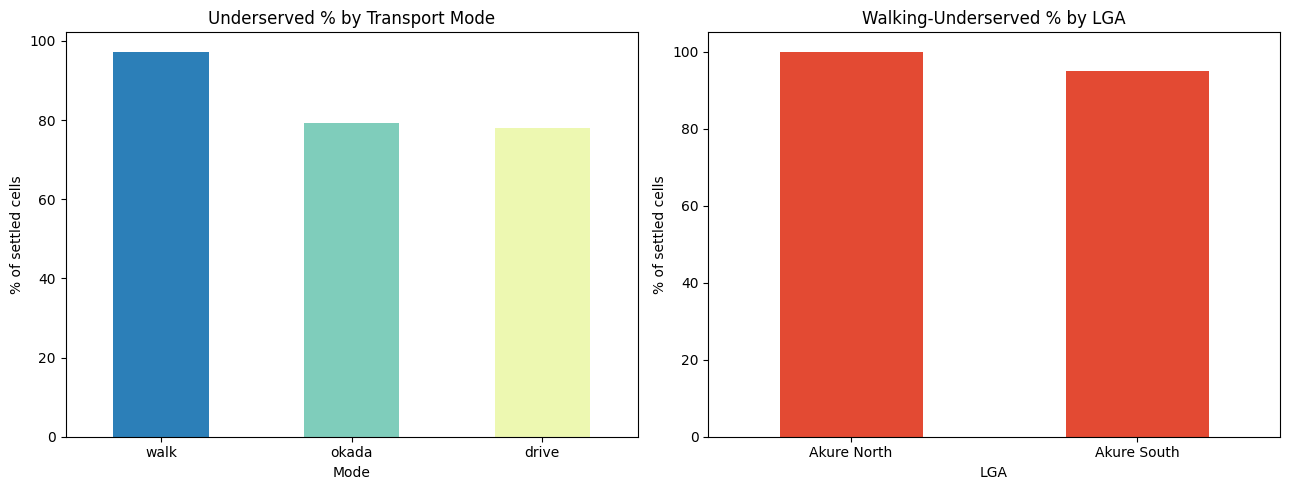

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mode_comparison_df["% underserved (>=1 service)"].plot(
    kind="bar", ax=axes[0], color=["#2c7fb8", "#7fcdbb", "#edf8b1"]
)
axes[0].set_title("Underserved % by Transport Mode")
axes[0].set_ylabel("% of settled cells")
axes[0].tick_params(axis="x", rotation=0)

lga_comparison_df[[c for c in lga_comparison_df.columns if "walk" in c]].plot(
    kind="bar", ax=axes[1], legend=False, color="#e34a33"
)
axes[1].set_title("Walking-Underserved % by LGA")
axes[1].set_ylabel("% of settled cells")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 7. Export

Saves the key tables to `reports/` for direct use in the written project
report and as supporting material for the ArcGIS StoryMap, plus the
combined dataset for Notebook 05 and the Streamlit dashboard.

In [8]:
import os

os.makedirs("../reports", exist_ok=True)

top_underserved.to_csv("../reports/top_underserved_settlements.csv", index=False)
mode_comparison_df.to_csv("../reports/mode_comparison_summary.csv")
lga_comparison_df.to_csv("../reports/lga_comparison_summary.csv")
combined.to_file("../data/processed/combined_access_scored.geojson", driver="GeoJSON")

print("Exported:")
print("  reports/top_underserved_settlements.csv")
print("  reports/mode_comparison_summary.csv")
print("  reports/lga_comparison_summary.csv")
print("  data/processed/combined_access_scored.geojson")


Exported:
  reports/top_underserved_settlements.csv
  reports/mode_comparison_summary.csv
  reports/lga_comparison_summary.csv
  data/processed/combined_access_scored.geojson


## 8. Summary

**What this notebook accomplished:** combined both LGAs' scored grids into
one comparative dataset, quantified how much the transport-mode assumption
changes the underserved picture, compared the two LGAs directly, and
cross-checked underserved findings against the completeness flags from
Notebook 02.

**Key findings tables produced:**

- `reports/top_underserved_settlements.csv` — ranked list for the report/StoryMap
- `reports/mode_comparison_summary.csv` — how much transport mode changes the picture
- `reports/lga_comparison_summary.csv` — Akure North vs. Akure South comparison
- `data/processed/combined_access_scored.geojson` — full combined dataset, also used directly by the Streamlit dashboard and by Notebook 05's kepler.gl visuals

**Next notebook:** `05_kepler_visualization.ipynb` turns this combined
dataset into polished, standalone map exports for embedding in the
StoryMap and README.